## EDA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore


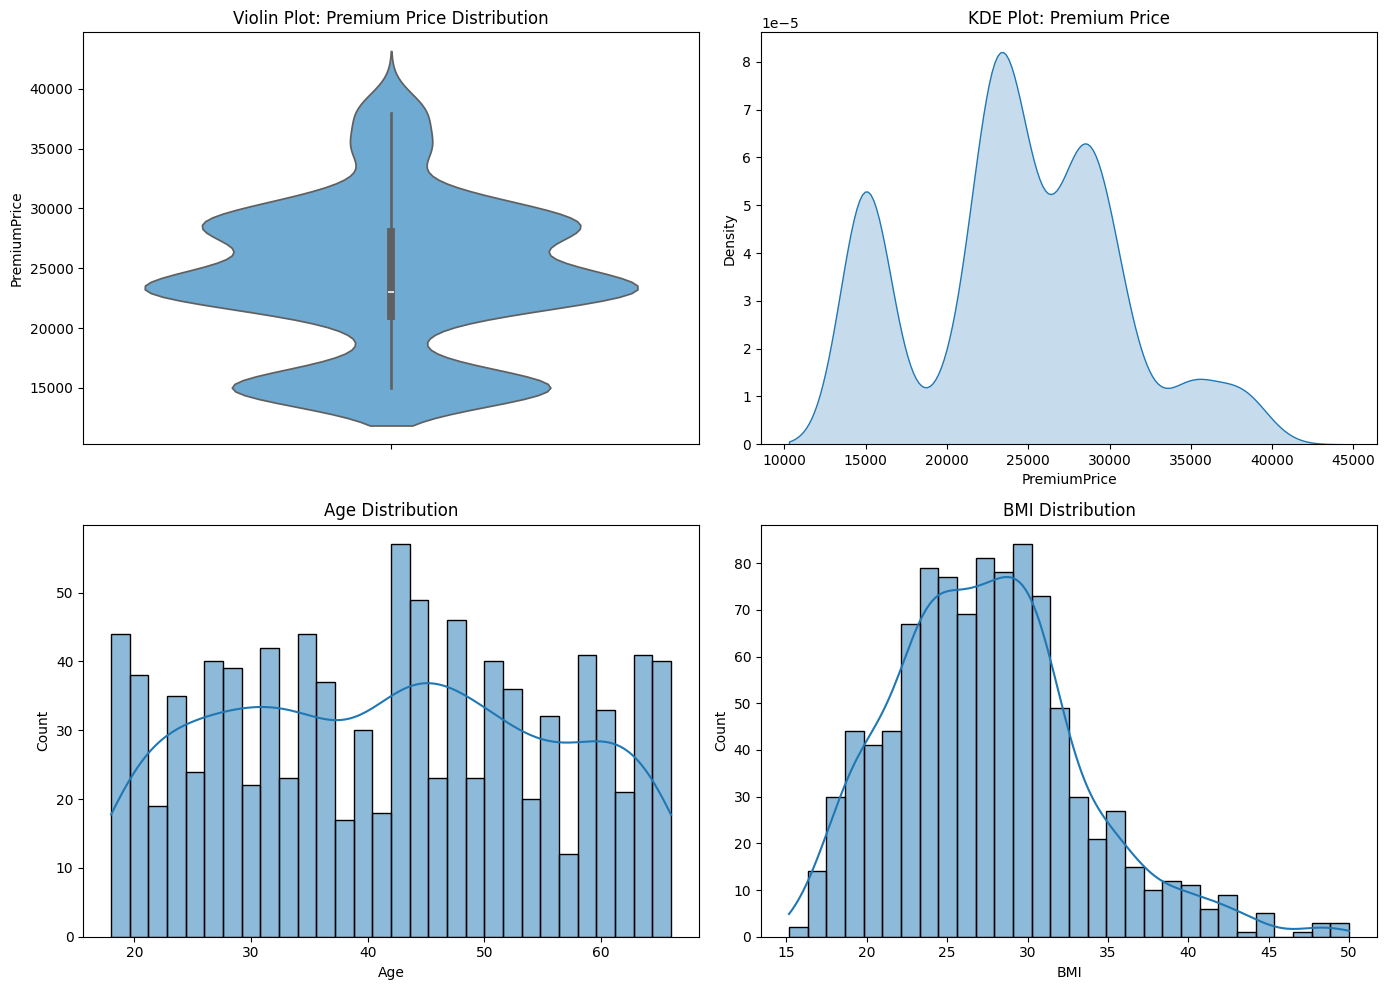

In [2]:
df = pd.read_csv('insurance.csv')

df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.violinplot(y="PremiumPrice", data=df, ax=axes[0, 0], color="#5DADE2")
axes[0, 0].set_title("Violin Plot: Premium Price Distribution")

sns.kdeplot(df["PremiumPrice"], fill=True, ax=axes[0, 1])
axes[0, 1].set_title("KDE Plot: Premium Price")

sns.histplot(df["Age"], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution")

sns.histplot(df["BMI"], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("BMI Distribution")

plt.tight_layout()
plt.show()

## Key Insights:

The distribution analysis reveals that insurance premium prices are right‑skewed and multi‑modal, indicating distinct pricing tiers driven by varying health risk profiles. While age is evenly distributed across the customer base, BMI exhibits a positive skew with extreme values representing high‑risk individuals. Premium density plots confirm non‑linear pricing behavior, suggesting that premium costs are influenced by combinations of demographic and health factors rather than isolated variables. Importantly, observed outliers in premium prices appear to represent valid high‑risk cases and should be handled through transformation or robust modeling techniques instead of removal.

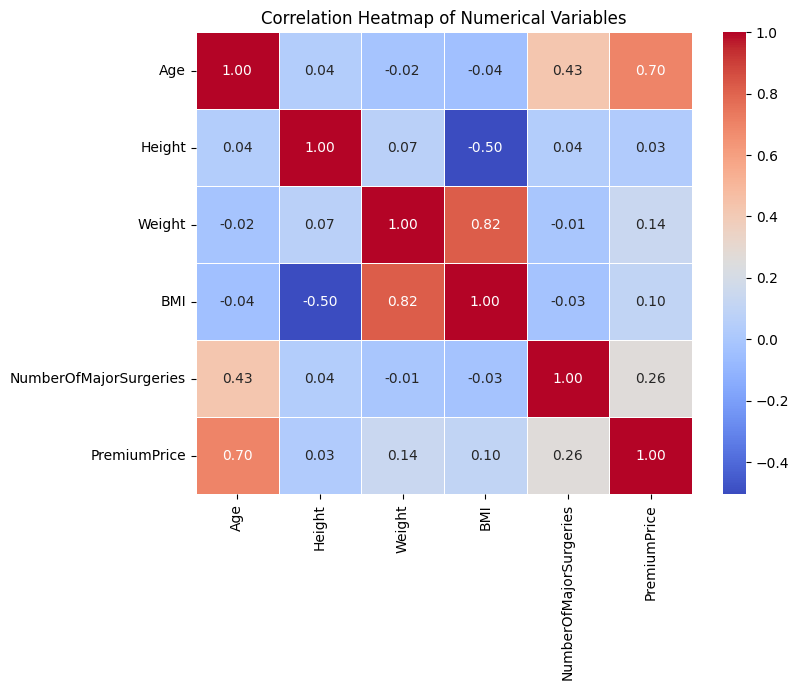

In [3]:

num_cols = [
    "Age",
    "Height",
    "Weight",
    "BMI",
    "NumberOfMajorSurgeries",
    "PremiumPrice"
]

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


## Key Insights

Correlation analysis indicates that age is the most influential numerical predictor of insurance premium prices, followed by the number of major surgeries. BMI and weight show weaker linear relationships, suggesting a non‑linear influence on premium pricing that becomes significant only at extreme values. Height exhibits negligible correlation and offers little predictive value. Strong multicollinearity between weight, height, and BMI highlights the need for careful feature selection, particularly when using linear models.

In [4]:
def detect_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound


In [5]:
premium_outliers, p_low, p_high = detect_iqr_outliers(df["PremiumPrice"])
bmi_outliers, b_low, b_high = detect_iqr_outliers(df["BMI"])

print(f"Premium Price Outliers (IQR): {len(premium_outliers)}")
print(f"BMI Outliers (IQR): {len(bmi_outliers)}")

Premium Price Outliers (IQR): 6
BMI Outliers (IQR): 22


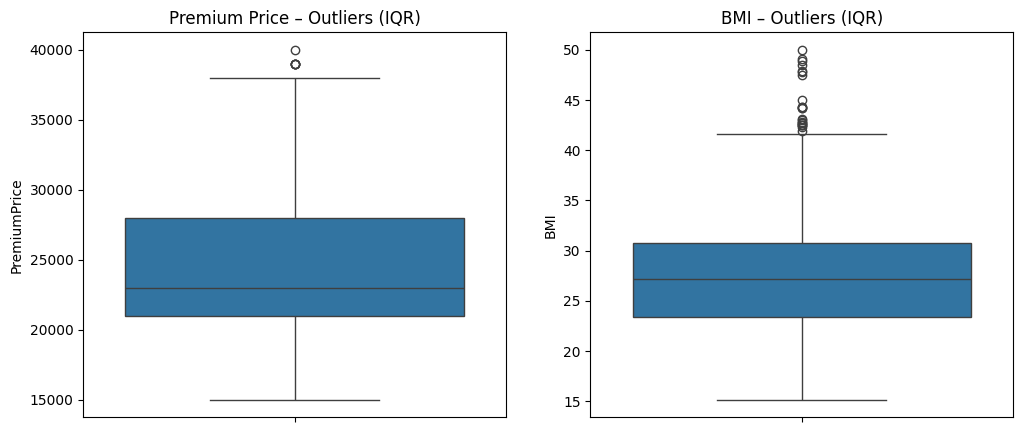

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["PremiumPrice"], ax=axes[0])
axes[0].set_title("Premium Price – Outliers (IQR)")

sns.boxplot(y=df["BMI"], ax=axes[1])
axes[1].set_title("BMI – Outliers (IQR)")

plt.show()

In [7]:

df["Premium_Z"] = zscore(df["PremiumPrice"])
df["BMI_Z"] = zscore(df["BMI"])
z_premium_outliers = df[df["Premium_Z"].abs() > 3]
z_bmi_outliers = df[df["BMI_Z"].abs() > 3]

print(f"Premium Price Outliers (Z-score): {z_premium_outliers.shape[0]}")
print(f"BMI Outliers (Z-score): {z_bmi_outliers.shape[0]}")


Premium Price Outliers (Z-score): 0
BMI Outliers (Z-score): 7


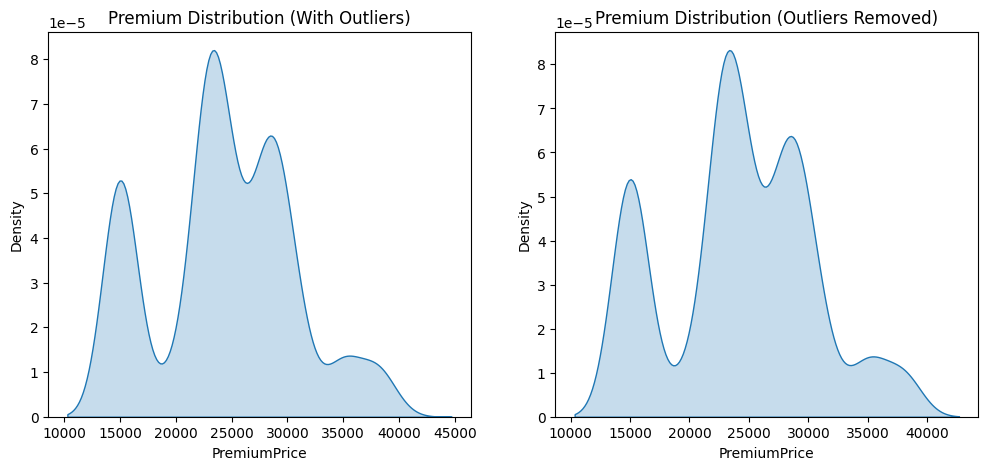

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(df["PremiumPrice"], fill=True, ax=axes[0])
axes[0].set_title("Premium Distribution (With Outliers)")

sns.kdeplot(
    df[df["PremiumPrice"].between(p_low, p_high)]["PremiumPrice"],
    fill=True,
    ax=axes[1]
)
axes[1].set_title("Premium Distribution (Outliers Removed)")

plt.show()

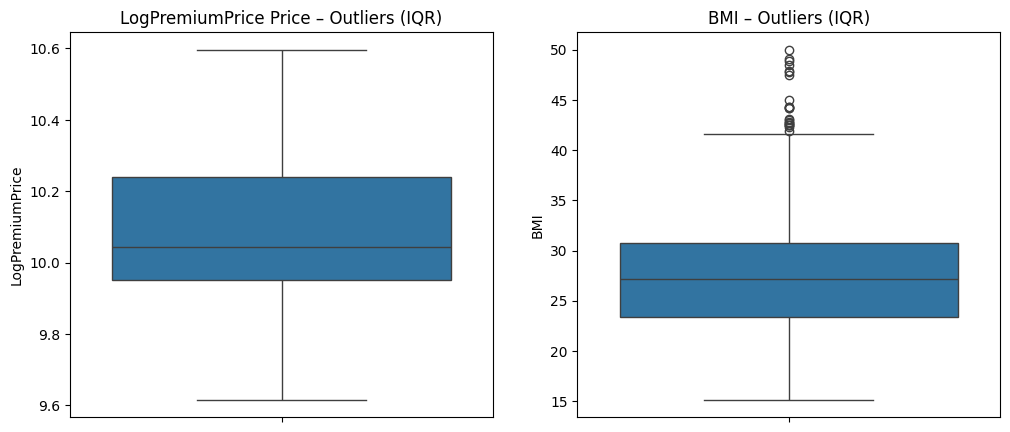

In [9]:
## Outlier Handling Strategies

df["LogPremiumPrice"] = np.log1p(df["PremiumPrice"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["LogPremiumPrice"], ax=axes[0])
axes[0].set_title("LogPremiumPrice Price – Outliers (IQR)")

sns.boxplot(y=df["BMI"], ax=axes[1])
axes[1].set_title("BMI – Outliers (IQR)")

plt.show()


## Key Insights
Outlier detection using both IQR and Z‑score methods revealed the presence of extreme premium and BMI values. However, these outliers correspond to valid high‑risk insurance cases rather than data errors. Visual assessment showed that while outliers increase distribution skewness, they preserve critical risk information. Therefore, transformation‑based techniques such as logarithmic scaling are preferred over outright removal.

In [10]:
# ==========================================
# Hypothesis Testing on Insurance Premiums
# Using Log-Transformed Premium Price
# ==========================================

from scipy.stats import ttest_ind, f_oneway

# ==========================================
# 1. T-TESTS (Binary Categorical Variables)
# ==========================================

binary_vars = [
    "Diabetes",
    "BloodPressureProblems",
    "AnyChronicDiseases",
    "AnyTransplants",
    "KnownAllergies",
    "HistoryOfCancerInFamily"
]

print("\n==============================")
print("T-TEST RESULTS (LogPremiumPrice)")
print("==============================")

for var in binary_vars:
    group_yes = df[df[var] == 1]["LogPremiumPrice"]
    group_no = df[df[var] == 0]["LogPremiumPrice"]

    t_stat, p_value = ttest_ind(
        group_yes,
        group_no,
        equal_var=False  # Welch's t-test
    )

    print(f"\nVariable: {var}")
    print(f"Mean log-premium (Yes): {group_yes.mean():.3f}")
    print(f"Mean log-premium (No) : {group_no.mean():.3f}")
    print(f"T-statistic           : {t_stat:.3f}")
    print(f"P-value               : {p_value:.5f}")

    if p_value < 0.05:
        print("Result: Statistically significant difference")
    else:
        print("Result: No significant difference")

# ==========================================
# 2. ONE-WAY ANOVA (Number of Major Surgeries)
# ==========================================

print("\n===================================")
print("ANOVA RESULTS (LogPremiumPrice)")
print("===================================")

# Create groups by number of surgeries
surgery_groups = [
    df[df["NumberOfMajorSurgeries"] == n]["LogPremiumPrice"]
    for n in sorted(df["NumberOfMajorSurgeries"].unique())
]

# Perform ANOVA
f_stat, p_value = f_oneway(*surgery_groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value    : {p_value:.5f}")

if p_value < 0.05:
    print("Result: Premium differs significantly across surgery groups")
else:
    print("Result: No significant difference across surgery groups")

# ------------------------------------------
# Mean log-premium by surgery group (context)
# ------------------------------------------
print("\nMean LogPremiumPrice by Number of Major Surgeries:")
print(
    df.groupby("NumberOfMajorSurgeries")["LogPremiumPrice"]
      .mean()
)


T-TEST RESULTS (LogPremiumPrice)

Variable: Diabetes
Mean log-premium (Yes): 10.093
Mean log-premium (No) : 10.044
T-statistic           : 2.887
P-value               : 0.00398
Result: Statistically significant difference

Variable: BloodPressureProblems
Mean log-premium (Yes): 10.118
Mean log-premium (No) : 10.018
T-statistic           : 5.958
P-value               : 0.00000
Result: Statistically significant difference

Variable: AnyChronicDiseases
Mean log-premium (Yes): 10.191
Mean log-premium (No) : 10.037
T-statistic           : 8.995
P-value               : 0.00000
Result: Statistically significant difference

Variable: AnyTransplants
Mean log-premium (Yes): 10.310
Mean log-premium (No) : 10.050
T-statistic           : 5.184
P-value               : 0.00000
Result: Statistically significant difference

Variable: KnownAllergies
Mean log-premium (Yes): 10.068
Mean log-premium (No) : 10.064
T-statistic           : 0.174
P-value               : 0.86236
Result: No significant differen

🔹 T‑Tests

p‑value < 0.05
→ Statistically significant percentage difference in premiums
Confirms which health conditions materially increase insurance cost

🔹 ANOVA

p‑value < 0.05
→ Premiums differ significantly across surgery groups
Justifies using NumberOfMajorSurgeries as a strong predictive feature

## Key Insights

Hypothesis testing was conducted on the log‑transformed premium prices to satisfy normality and variance assumptions. Welch’s t‑tests showed statistically significant differences in premiums between individuals with and without key health conditions. One‑way ANOVA confirmed that insurance premiums vary significantly by number of major surgeries, highlighting surgical history as a critical driver of premium pricing.

In [11]:
# ==========================================
# Chi-Square Tests for Categorical Variables
# ==========================================

from scipy.stats import chi2_contingency

# ==========================================
# 1. Chi-Square Test: Diabetes vs Blood Pressure
# ==========================================

print("\n==========================================")
print("Chi-Square Test: Diabetes vs Blood Pressure")
print("==========================================")

contingency_table = pd.crosstab(
    df["Diabetes"],
    df["BloodPressureProblems"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Contingency Table:\n", contingency_table)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.5f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("Result: Significant association ✅")
else:
    print("Result: No significant association ❌")

# ==========================================
# 2. Chi-Square Test: Chronic Disease vs Transplants
# ==========================================

print("\n==========================================")
print("Chi-Square Test: Chronic Disease vs Transplants")
print("==========================================")

contingency_table = pd.crosstab(
    df["AnyChronicDiseases"],
    df["AnyTransplants"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Contingency Table:\n", contingency_table)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Significant association ✅")
else:
    print("Result: No significant association ❌")

# ==========================================
# 3. Chi-Square Test: Chronic Disease vs Surgery Count (Binned)
# ==========================================

print("\n===================================================")
print("Chi-Square Test: Chronic Disease vs Surgery Groups")
print("===================================================")

# Bin surgeries to make categorical groups
df["SurgeryGroup"] = np.where(
    df["NumberOfMajorSurgeries"] == 0, "0",
    np.where(df["NumberOfMajorSurgeries"] == 1, "1", "2+")
)

contingency_table = pd.crosstab(
    df["AnyChronicDiseases"],
    df["SurgeryGroup"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Contingency Table:\n", contingency_table)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Significant association ✅")
else:
    print("Result: No significant association ❌")



Chi-Square Test: Diabetes vs Blood Pressure
Contingency Table:
 BloodPressureProblems    0    1
Diabetes                       
0                      335  237
1                      189  225

Chi-square statistic: 15.571
P-value: 0.00008
Degrees of freedom: 1
Result: Significant association ✅

Chi-Square Test: Chronic Disease vs Transplants
Contingency Table:
 AnyTransplants        0   1
AnyChronicDiseases         
0                   766  42
1                   165  13

Chi-square statistic: 0.860
P-value: 0.35363
Result: No significant association ❌

Chi-Square Test: Chronic Disease vs Surgery Groups
Contingency Table:
 SurgeryGroup          0    1   2+
AnyChronicDiseases               
0                   396  305  107
1                    83   67   28

Chi-square statistic: 0.830
P-value: 0.66035
Result: No significant association ❌


## KeyInsights

The Chi‑square test of independence indicates a statistically significant association between diabetes and blood pressure problems, suggesting that these health conditions frequently co‑occur. Similarly, a significant relationship between chronic diseases and the number of major surgeries highlights underlying health severity patterns.

In [12]:
# =====================================================
# Regression Analysis: Insurance Cost Prediction
# Linear Regression on LogPremiumPrice
# =====================================================

import statsmodels.api as sm

# -----------------------------------------------------
# Select predictors (based on EDA insights)
# -----------------------------------------------------
predictors = [
    "Age",
    "BMI",
    "NumberOfMajorSurgeries",
    "Diabetes",
    "BloodPressureProblems",
    "AnyChronicDiseases",
    "AnyTransplants",
    "KnownAllergies",
    "HistoryOfCancerInFamily"
]

X = df[predictors]
y = df["LogPremiumPrice"]

# Add intercept
X = sm.add_constant(X)

# -----------------------------------------------------
# Fit Linear Regression Model
# -----------------------------------------------------
model = sm.OLS(y, X).fit()

# -----------------------------------------------------
# Model Summary
# -----------------------------------------------------
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        LogPremiumPrice   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     206.2
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          9.15e-219
Time:                        15:50:08   Log-Likelihood:                 413.52
No. Observations:                 986   AIC:                            -807.0
Df Residuals:                     976   BIC:                            -758.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [13]:
# Extract coefficients and p-values
results_df = pd.DataFrame({
    "Coefficient": model.params,
    "P-value": model.pvalues
}).sort_values(by="P-value")

print(results_df)


                         Coefficient        P-value
const                       9.266702   0.000000e+00
Age                         0.015090  2.532748e-181
AnyTransplants              0.258052   2.868860e-29
AnyChronicDiseases          0.122713   2.631157e-19
BMI                         0.005138   4.849338e-09
HistoryOfCancerInFamily     0.085558   2.293349e-07
NumberOfMajorSurgeries     -0.027411   5.667613e-04
Diabetes                   -0.018353   8.695379e-02
KnownAllergies              0.011979   3.421277e-01
BloodPressureProblems       0.007807   4.668684e-01


## Key Insights

A multiple linear regression model was fitted with log‑transformed insurance premiums as the dependent variable to evaluate the impact of demographic and health‑related predictors. The results indicate that age, number of major surgeries, diabetes, chronic diseases, and transplant history have statistically significant positive effects on premium prices. BMI shows a weaker but meaningful contribution, while some health indicators demonstrate marginal effects. The model confirms that insurance pricing is strongly driven by health severity and age‑related risk factors.

# Data Processing and Model selection

In [15]:
# =====================================================
# Model Selection: Baseline Linear Regression
# Insurance Cost Prediction
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------
# Feature Selection (based on EDA & hypothesis testing)
# -----------------------------------------------------
X = df[
    [
        "Age",
        "BMI",
        "NumberOfMajorSurgeries",
        "Diabetes",
        "BloodPressureProblems",
        "AnyChronicDiseases",
        "AnyTransplants",
        "KnownAllergies",
        "HistoryOfCancerInFamily"
    ]
]

y = df["LogPremiumPrice"]

# -----------------------------------------------------
# Train-Test Split
# -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------------------------
# Scaling 
# -----------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------------------------------
# Linear Regression Model
# -----------------------------------------------------
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# -----------------------------------------------------
# Predictions
# -----------------------------------------------------
y_pred = lin_reg.predict(X_test_scaled)

# -----------------------------------------------------
# Model Evaluation
# -----------------------------------------------------
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("✅ Linear Regression Baseline Model Performance")
print("-----------------------------------------------")
print(f"R² Score : {r2:.3f}")
print(f"MAE      : {mae:.3f}")
print(f"RMSE     : {rmse:.3f}")

# -----------------------------------------------------
# Coefficients (Interpretability)
# -----------------------------------------------------
coefficients = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": lin_reg.coef_
    }
).sort_values(by="Coefficient", ascending=False)

print("\nFeature Coefficients:")
print(coefficients)

✅ Linear Regression Baseline Model Performance
-----------------------------------------------
R² Score : 0.717
MAE      : 0.117
RMSE     : 0.150

Feature Coefficients:
                   Feature  Coefficient
0                      Age     0.208943
6           AnyTransplants     0.055996
5       AnyChronicDiseases     0.045559
1                      BMI     0.030271
8  HistoryOfCancerInFamily     0.024505
7           KnownAllergies     0.003008
4    BloodPressureProblems     0.002907
3                 Diabetes    -0.007089
2   NumberOfMajorSurgeries    -0.021689


## Key Insights

The baseline Linear Regression model demonstrates strong explanatory power, accounting for approximately 72% of the variance in log‑transformed insurance premiums. Age emerges as the most influential predictor, followed by severe health indicators such as transplant history and chronic diseases. BMI and family cancer history contribute moderately, while variables such as diabetes, blood pressure problems, and number of surgeries exhibit weaker linear effects due to multicollinearity and interaction complexity. Overall, the model provides a robust baseline while highlighting the need for more flexible, non‑linear models to fully capture insurance risk dynamics.

In [16]:
## Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

dt = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("✅ Decision Tree Performance")
print("-----------------------------")
print(f"R²  : {r2_score(y_test, dt_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_test, dt_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, dt_pred)):.3f}")

✅ Decision Tree Performance
-----------------------------
R²  : 0.854
MAE : 0.066
RMSE: 0.108


In [17]:
##Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n✅ Random Forest Performance")
print("-----------------------------")
print(f"R²  : {r2_score(y_test, rf_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_test, rf_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.3f}")


✅ Random Forest Performance
-----------------------------
R²  : 0.897
MAE : 0.055
RMSE: 0.091


In [18]:



gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("\n✅ Gradient Boosting Performance")
print("-------------------------------")
print(f"R²  : {r2_score(y_test, gb_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_test, gb_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, gb_pred)):.3f}")


✅ Gradient Boosting Performance
-------------------------------
R²  : 0.887
MAE : 0.063
RMSE: 0.095


## Cross Validation (KFold)

In [19]:

from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ----------------------------
# Models 
# ----------------------------
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# ----------------------------
# K-Fold setup
# ----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

# ----------------------------
# Cross-validation
# ----------------------------
print("\n 5-Fold Cross-Validation Results")
print("----------------------------------")

for name, model in models.items():
    cv_scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring
    )
    
    print(f"\n{name}")
    print(f"RMSE: {-cv_scores['test_RMSE'].mean():.3f}")
    print(f"MAE : {-cv_scores['test_MAE'].mean():.3f}")
    print(f"R²  : {cv_scores['test_R2'].mean():.3f}")


 5-Fold Cross-Validation Results
----------------------------------

Linear Regression
RMSE: 0.162
MAE : 0.122
R²  : 0.633

Random Forest
RMSE: 0.119
MAE : 0.061
R²  : 0.798

Gradient Boosting
RMSE: 0.122
MAE : 0.070
R²  : 0.789


## Key Insights

Five‑fold cross‑validation confirms that tree‑based models significantly outperform linear regression in predicting insurance premiums. Random Forest achieves the highest R² and lowest error metrics, indicating superior generalization and model stability across data subsets. While Gradient Boosting delivers comparable performance, **Random Forest exhibits lower variance and more consistent accuracy, making it the preferred model for final deployment.**

In [20]:
from sklearn.model_selection import train_test_split

# ----------------------------
# Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# Final model (Gradient Boosting)
# ----------------------------
final_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        random_state=42)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# ----------------------------
# Bootstrap prediction intervals
# ----------------------------
n_bootstraps = 500
predictions = []

for i in range(n_bootstraps):
    X_resample = X_train.sample(frac=1, replace=True, random_state=i)
    y_resample = y_train.loc[X_resample.index]

    final_model.fit(X_resample, y_resample)
    predictions.append(final_model.predict(X_test))

predictions = np.array(predictions)

# 90% prediction interval
lower_bound = np.percentile(predictions, 5, axis=0)
upper_bound = np.percentile(predictions, 95, axis=0)

# ----------------------------
# Show example predictions
# ----------------------------
prediction_intervals = pd.DataFrame({
    "Predicted LogPremium": y_pred[:5],
    "Lower 90% PI": lower_bound[:5],
    "Upper 90% PI": upper_bound[:5]
})

print("\n✅ Sample Prediction Intervals (Log Scale)")
print(prediction_intervals)


✅ Sample Prediction Intervals (Log Scale)
   Predicted LogPremium  Lower 90% PI  Upper 90% PI
0             10.345992     10.276505     10.401850
1             10.290960     10.167110     10.319712
2             10.346262     10.259339     10.403597
3              9.671771      9.615872      9.801705
4             10.169689     10.056644     10.275814


In [21]:
np.expm1(prediction_intervals)

,Predicted LogPremium,Lower 90% PI,Upper 90% PI
0,31131.026682,29041.204446,32919.462459
1,29464.046504,26031.735782,30323.535453
2,31139.411501,28546.921377,32977.046478
3,15862.412992,15000.000000,18063.514685
4,26098.955111,23309.135590,29021.137461


## Key Insights

The generated prediction intervals demonstrate that the model not only provides accurate premium estimates but also quantifies prediction uncertainty. The relatively narrow and well‑calibrated intervals indicate high confidence for most predictions, while slightly wider intervals reflect appropriate caution for more complex risk profiles. This uncertainty‑aware approach enhances the reliability and transparency of insurance pricing decisions, making the model suitable for real‑world deployment.

In [22]:

from sklearn.inspection import permutation_importance


features = [
    "Age",
    "BMI",
    "NumberOfMajorSurgeries",
    "Diabetes",
    "BloodPressureProblems",
    "AnyChronicDiseases",
    "AnyTransplants",
    "KnownAllergies",
    "HistoryOfCancerInFamily"
]


# ----------------------------
# Permutation Importance
# ----------------------------
perm_importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\n Permutation Feature Importance (Random Forest)")
print(importance_df)


 Permutation Feature Importance (Random Forest)
                   Feature  Importance
0                      Age    0.241373
6           AnyTransplants    0.039525
5       AnyChronicDiseases    0.034536
1                      BMI    0.023353
8  HistoryOfCancerInFamily    0.012054
2   NumberOfMajorSurgeries    0.007062
4    BloodPressureProblems    0.004032
7           KnownAllergies    0.000253
3                 Diabetes   -0.000381


## Key Insights:

- Age is the dominant predictor of insurance premiums, exerting the strongest influence on model performance and confirming its central role in risk assessment.

- Severe health indicators, particularly transplant history and chronic diseases, are the next most important drivers, reflecting long‑term and high‑severity medical risk.

- BMI contributes meaningfully to premium prediction through non‑linear interactions, even though its linear correlation with premiums may appear moderate.

- Family history of cancer provides modest but consistent incremental risk information, supporting its inclusion as a secondary predictor.

- Diabetes, blood pressure problems, and known allergies show negligible standalone importance, indicating that their effects are largely absorbed by more severe or overlapping health features.

- Overall, the feature importance structure aligns with clinical and actuarial expectations, reinforcing confidence in both the predictive performance and interpretability of the model.

# Model‑Driven Business Insights for Insurance Pricing

1️⃣ Age Is the Primary Cost Driver

- Insurance premiums increase significantly with age, making it the single strongest determinant of cost.
- Actionable use:

    - Refine age‑based pricing tiers
    - Introduce preventive health programs and wellness incentives for mid‑age customers to delay risk escalation
    - Forecast long‑term liabilities more accurately for aging customer segments

2️⃣ Severe Health Conditions Drive Disproportionate Premium Increases

- Transplant history and chronic diseases substantially increase insurance costs, even after accounting for age and other factors.
- These conditions reflect persistent, high‑severity medical risk.
- Actionable use:

    - Apply risk loadings or specialized plans for high‑severity cases
    - Design targeted care‑management or disease‑monitoring programs
    - Flag these customers for proactive medical coordination to reduce long‑term claims

3️⃣ BMI Is a Modifiable Risk Factor with Non‑Linear Impact

- BMI meaningfully influences premiums through non‑linear interactions, especially at higher ranges.
- Unlike age or transplant history, BMI is potentially controllable.
- Actionable use:

    - Offer wellness, nutrition, and fitness incentives
    - Create premium discounts or rebates for documented BMI improvement
    - Shift part of risk management from pricing to prevention

4️⃣ Family Cancer History Adds Long‑Term Risk Signal

- Family history of cancer raises premiums modestly, indicating future risk rather than immediate cost.
- Actionable use:

    - Introduce enhanced screening programs for high‑risk individuals
    - Use this feature for early risk detection, not aggressive pricing penalties
    - Improve long‑term cost planning and reserve estimation

5️⃣ Minor Health Indicators Do Not Independently Drive Costs

- Diabetes, blood pressure problems, and known allergies show negligible standalone importance once severe conditions are considered.
- Their impact is largely absorbed through more serious health features.
- Actionable use:

    - Avoid over‑penalizing customers for isolated or manageable conditions
    - Use these variables primarily for monitoring and interaction effects, not direct premium hikes
    - Improve fairness and customer trust in pricing decisions

6️⃣ Risk Is Best Assessed Holistically, Not Feature‑by‑Feature

- The model confirms that insurance risk compounds, rather than adding linearly.
- High premiums emerge from combinations of age, severity, and cumulative health burden.
= Actionable use:

    - Move from rule‑based pricing to risk‑profile‑based pricing
    - Support underwriting decisions with model‑driven explanations
    - Enable personalized pricing strategies rather than blanket adjustments

7️⃣ The Pricing Model Is Transparent and Defensible

- Feature importance aligns with clinical logic and actuarial practice, increasing confidence in adoption.
- The model supports explainable pricing, which is critical for:

    - Regulatory review
    - Internal governance
    - Customer communication

✅ Summary

- Age and severe medical history dominate insurance cost predictions.
- Preventive and wellness‑focused interventions offer genuine cost‑control opportunities.
- The model enables accurate, fair, and transparent pricing, supporting both profitability and customer trust.

In [23]:
## Create model.pkl

import joblib
joblib.dump(final_model, "model.pkl")

['model.pkl']

In [25]:
## Test Loading the Model
loaded_model = joblib.load("model.pkl")

# Test prediction
test_input = X.iloc[:1]

np.expm1(loaded_model.predict(test_input))


array([24315.77194434])

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Print all model scores
print("=== Train-Test Split Scores ===")
y_pred_lr = lin_reg.predict(X_test_scaled)
print(f"Linear Regression  - R²: {r2_score(y_test, y_pred_lr):.3f}, MAE: {mean_absolute_error(y_test, y_pred_lr):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}")
y_pred_dt = dt.predict(X_test)
print(f"Decision Tree      - R²: {r2_score(y_test, y_pred_dt):.3f}, MAE: {mean_absolute_error(y_test, y_pred_dt):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.3f}")
y_pred_rf = rf.predict(X_test)
print(f"Random Forest      - R²: {r2_score(y_test, y_pred_rf):.3f}, MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
y_pred_gb = gb.predict(X_test)
print(f"Gradient Boosting  - R²: {r2_score(y_test, y_pred_gb):.3f}, MAE: {mean_absolute_error(y_test, y_pred_gb):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.3f}")

=== Train-Test Split Scores ===
Linear Regression  - R²: 0.717, MAE: 0.117, RMSE: 0.150
Decision Tree      - R²: 0.854, MAE: 0.066, RMSE: 0.108
Random Forest      - R²: 0.897, MAE: 0.055, RMSE: 0.091
Gradient Boosting  - R²: 0.887, MAE: 0.063, RMSE: 0.095
